## Bigmart Sales Analysis

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df = pd.read_csv('C:\\Users\\dell\\Downloads\\archive (1)\\bigmart.csv')

In [201]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [202]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [203]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

<Axes: >

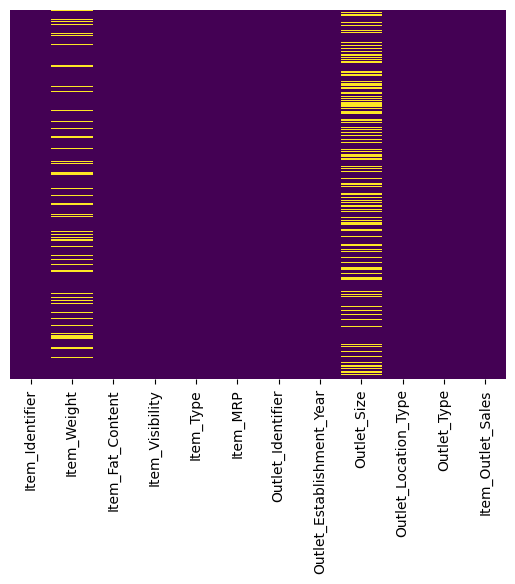

In [212]:
sns.heatmap(data=df.isnull(),cmap='viridis',cbar=False,yticklabels=False)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


<Axes: xlabel='Item_Outlet_Sales', ylabel='Count'>

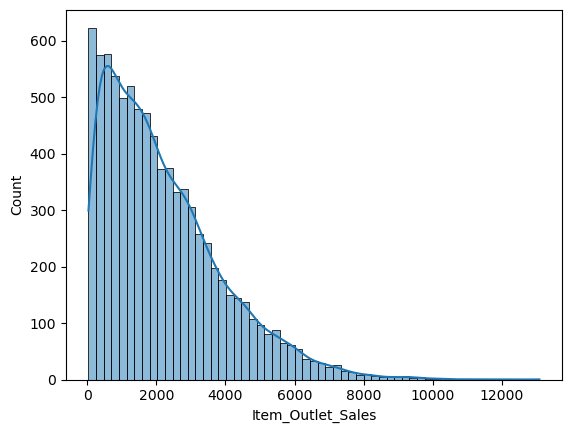

In [206]:
sns.histplot(df,x='Item_Outlet_Sales',kde=True)

<Axes: xlabel='Item_Outlet_Sales', ylabel='Item_Type'>

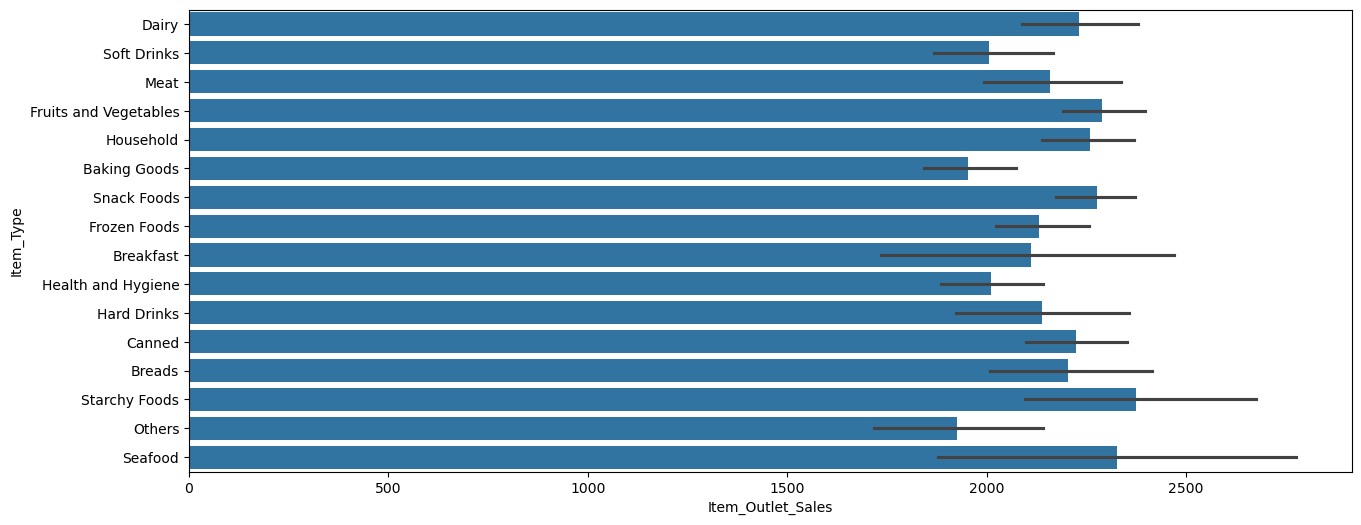

In [216]:
plt.figure(figsize=(15,6))
sns.barplot(df,y='Item_Type',x='Item_Outlet_Sales')

<Axes: xlabel='Item_Visibility', ylabel='Item_Type'>

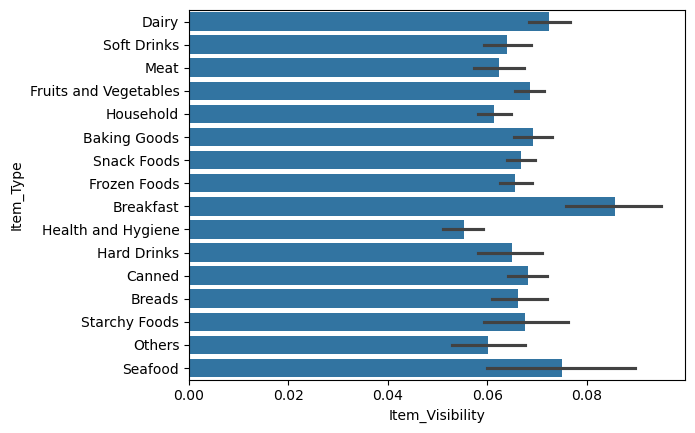

In [213]:
sns.barplot(df,x='Item_Visibility',y='Item_Type')

<Axes: xlabel='count', ylabel='Item_Type'>

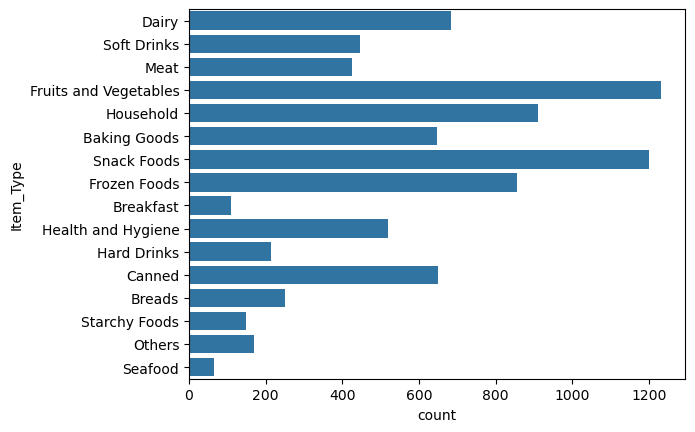

In [215]:
sns.countplot(df,y='Item_Type')

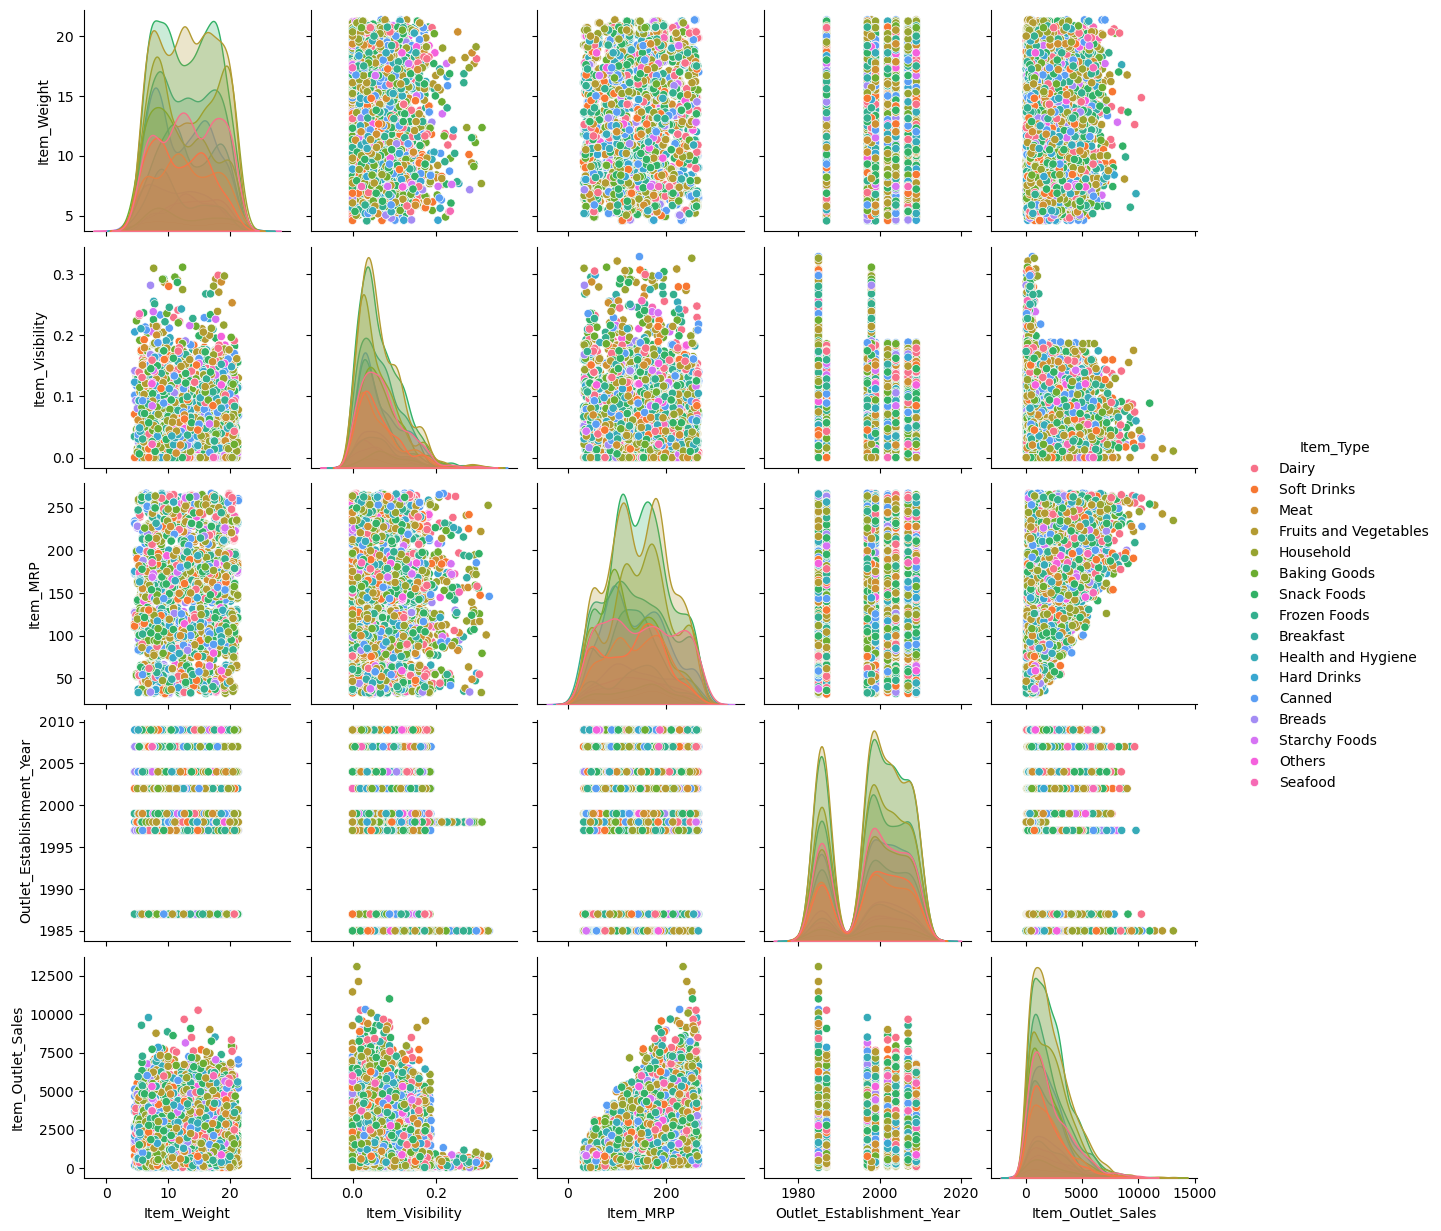

In [219]:
sns.pairplot(df, hue='Item_Type') 
plt.show()

<Axes: xlabel='Item_Outlet_Sales'>

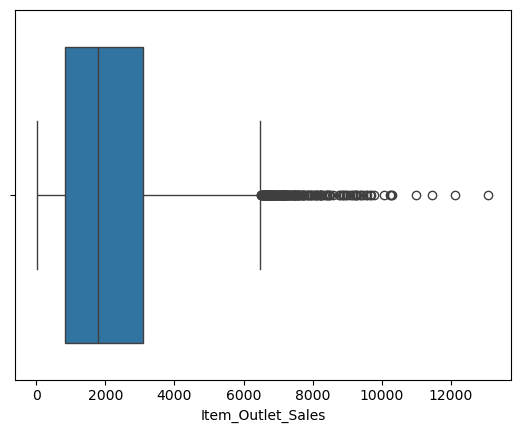

In [12]:
sns.boxplot(df,x='Item_Outlet_Sales')

## observations
- we can see that target value having the outliers.
- we can deal with the IQR mrthod

In [13]:
Q1 = df['Item_Outlet_Sales'].quantile(0.25)
Q3 = df['Item_Outlet_Sales'].quantile(0.75)

In [14]:
IQR = Q3 - Q1

In [15]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3  + (1.5 * IQR)

In [23]:
#outliers = df[(df['Item_Outlet_Sales'] >= lower_bound) | (df['Item_Outlet_Sales'] <= upper_bound)]

In [25]:
df = df[df['Item_Outlet_Sales'].apply(lambda x: lower_bound <= x <= upper_bound)]

Text(0.5, 1.0, 'boxplot of Item_Outlet_Sales')

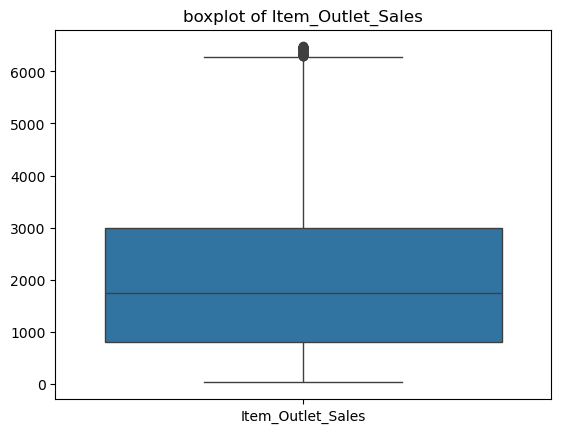

In [26]:
sns.boxplot(data=df[['Item_Outlet_Sales']])
plt.title("boxplot of Item_Outlet_Sales")

In [32]:
df.Item_Weight.value_counts().mode()[0]

5

In [36]:
corr = df.select_dtypes(include = np.number).corr()

<Axes: >

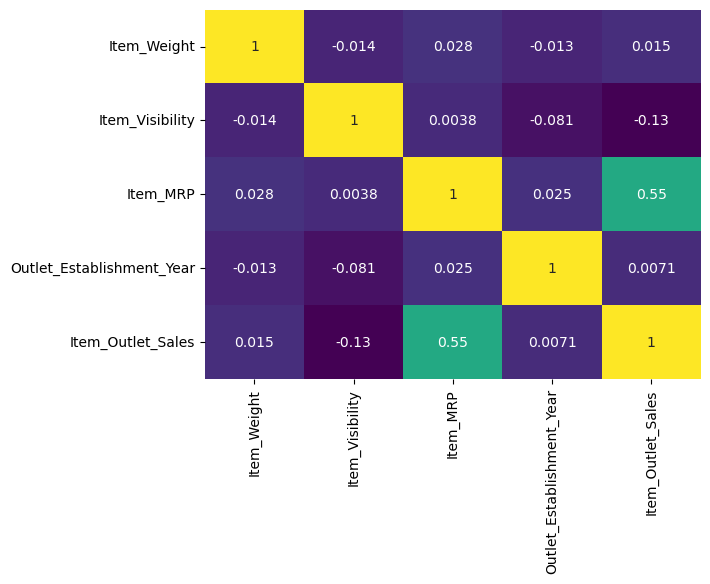

In [37]:
sns.heatmap(corr,cmap='viridis',cbar=False,annot=True)

In [38]:
dataset = df.copy()

In [46]:
df= df.drop('Item_Identifier',axis=1)

In [47]:
df= df.drop('Outlet_Identifier',axis=1)

In [48]:
inputs = df.drop('Item_Outlet_Sales',axis=1)

In [53]:
targets = df['Item_Outlet_Sales']

In [51]:
inputs.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1


In [55]:
targets.head()

0    3735.1380
1     443.4228
2    2097.2700
3     732.3800
4     994.7052
Name: Item_Outlet_Sales, dtype: float64

In [59]:
numerical_cols = inputs.select_dtypes(include =np.number).columns

In [60]:
categorical_cols = inputs.select_dtypes(include = 'object').columns

In [61]:
numerical_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')

In [62]:
categorical_cols

Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')

## imputing the null values

In [68]:
df.isnull().sum()

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [64]:
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

In [67]:
mode_outlet_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_outlet_size)

In [74]:
df[numerical_cols].isnull().sum(),df[categorical_cols].isnull().sum()

(Item_Weight                  0
 Item_Visibility              0
 Item_MRP                     0
 Outlet_Establishment_Year    0
 dtype: int64,
 Item_Fat_Content        0
 Item_Type               0
 Outlet_Size             0
 Outlet_Location_Type    0
 Outlet_Type             0
 dtype: int64)

## scaling the numerical_cols

In [76]:
from sklearn.preprocessing import MinMaxScaler

In [77]:
scaler = MinMaxScaler().fit(df[numerical_cols])

In [78]:
df[numerical_cols] = scaler.transform(df[numerical_cols])

In [80]:
df[numerical_cols].head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
0,0.282525,0.048866,0.927507,0.583333
1,0.081274,0.058705,0.072068,1.000000
2,0.770765,0.051037,0.468288,0.583333
3,0.871986,0.000000,0.640093,0.541667
4,0.260494,0.000000,0.095805,0.083333


## scaling the categorical_cols

In [83]:
categorical_cols

Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')

In [84]:
df.Item_Fat_Content.unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [85]:
df.Item_Type.unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [86]:
df.Outlet_Size.unique()

array(['Medium', 'High', 'Small'], dtype=object)

In [87]:
df.Outlet_Location_Type.unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [88]:
df.Outlet_Type.unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

## using OneHotEncoder
- we can also use the `LabelEncoder`.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [90]:
encoder = OneHotEncoder(sparse_output = False,handle_unknown = 'ignore').fit(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_cols

array(['Item_Fat_Content_LF', 'Item_Fat_Content_Low Fat',
       'Item_Fat_Content_Regular', 'Item_Fat_Content_low fat',
       'Item_Fat_Content_reg', 'Item_Type_Baking Goods',
       'Item_Type_Breads', 'Item_Type_Breakfast', 'Item_Type_Canned',
       'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household',
       'Item_Type_Meat', 'Item_Type_Others', 'Item_Type_Seafood',
       'Item_Type_Snack Foods', 'Item_Type_Soft Drinks',
       'Item_Type_Starchy Foods', 'Outlet_Size_High',
       'Outlet_Size_Medium', 'Outlet_Size_Small',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Type_Grocery Store',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'], dtype=object)

In [91]:
df[encoded_cols] = encoder.transform(df[categorical_cols])

In [92]:
df[encoded_cols].head()

,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## combining the both the dataframes

In [95]:
scaled_df = pd.concat([df[numerical_cols],df[encoded_cols]],axis=1)

In [96]:
scaled_df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Baking Goods,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.282525,0.048866,0.927507,0.583333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.081274,0.058705,0.072068,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.770765,0.051037,0.468288,0.583333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.871986,0.000000,0.640093,0.541667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.260494,0.000000,0.095805,0.083333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [221]:
corr_matrix=scaled_df.corr()

In [222]:
corr_unstacked = corr_matrix.unstack()
# Remove self-correlations
corr_unstacked = corr_unstacked[corr_unstacked < 1]


In [223]:
top_10_corr = corr_unstacked.abs().sort_values(ascending=False).head(10)
print(top_10_corr)

Item_Fat_Content_Regular       Item_Fat_Content_Low Fat         0.870466
Item_Fat_Content_Low Fat       Item_Fat_Content_Regular         0.870466
Outlet_Size_Medium             Outlet_Size_Small                0.780890
Outlet_Size_Small              Outlet_Size_Medium               0.780890
Outlet_Location_Type_Tier 3    Outlet_Type_Supermarket Type1    0.629717
Outlet_Type_Supermarket Type1  Outlet_Location_Type_Tier 3      0.629717
Outlet_Location_Type_Tier 2    Outlet_Location_Type_Tier 3      0.556448
Outlet_Location_Type_Tier 3    Outlet_Location_Type_Tier 2      0.556448
Outlet_Type_Grocery Store      Outlet_Type_Supermarket Type1    0.537563
Outlet_Type_Supermarket Type1  Outlet_Type_Grocery Store        0.537563
dtype: float64


In [232]:
top_pairs = top_10_corr.index.tolist()

In [233]:
# Extract unique features involved in top 10 correlations
features = list(set([i for pair in top_pairs for i in pair]))

# Subset the correlation matrix
top_corr_matrix = corr_matrix.loc[features, features]


<Axes: >

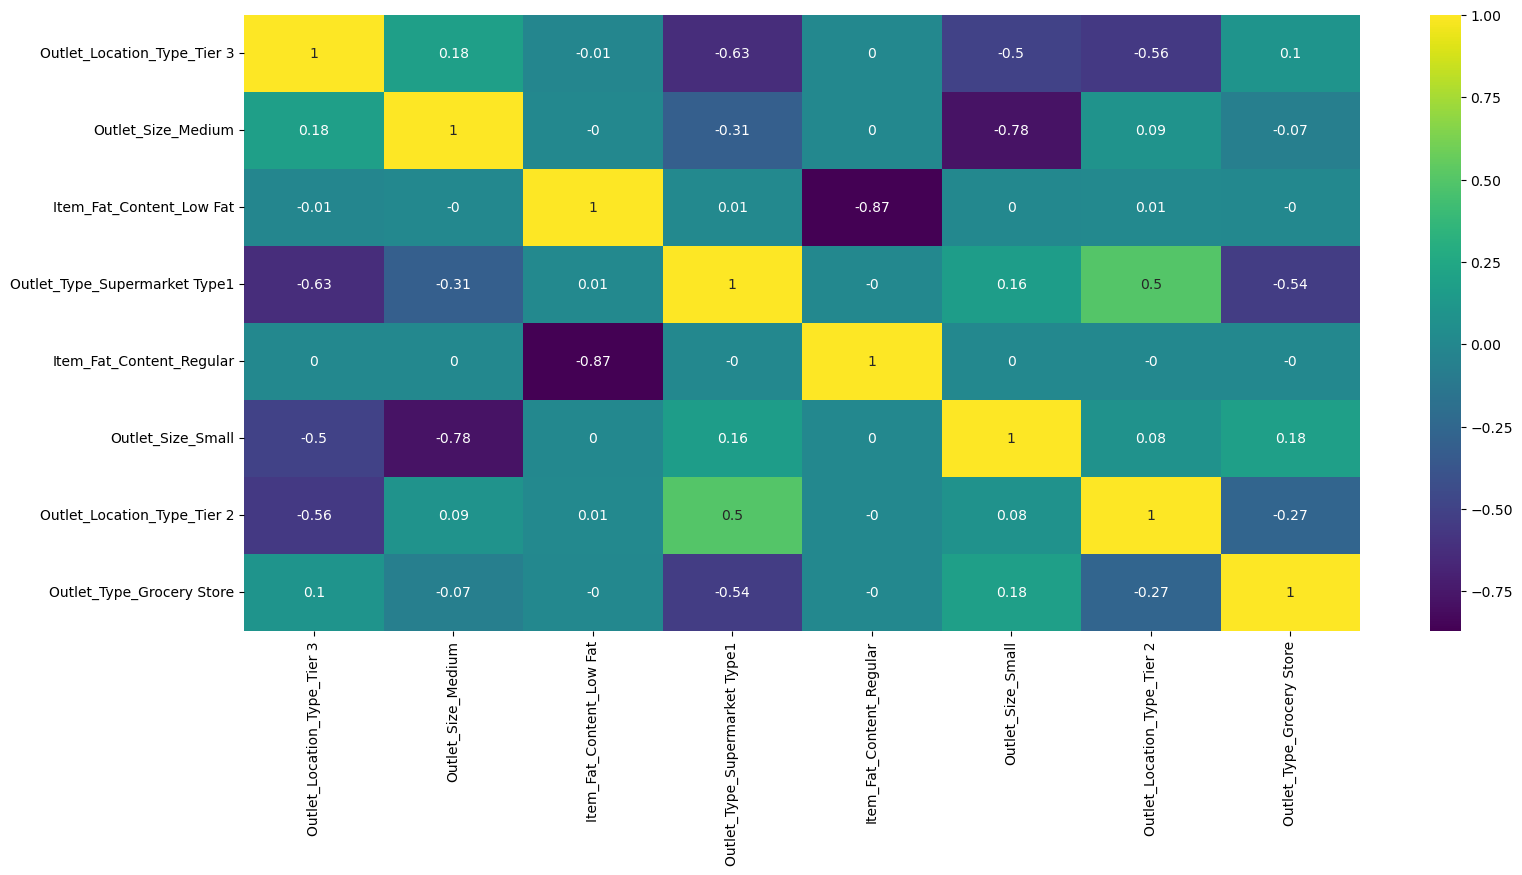

In [234]:
plt.figure(figsize=(18,8))
sns.heatmap(round(top_corr_matrix,2),annot=True,cmap='viridis')

## splitting the data into train and test

In [97]:
from sklearn.model_selection import train_test_split

In [99]:
X_train,X_test,y_train,y_test = train_test_split(scaled_df,targets,test_size = 0.3,random_state=42)

In [100]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((5835, 35), (2502, 35), (5835,), (2502,))

## Model Training and Evalution

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [114]:
model = LinearRegression().fit(X_train,y_train)
preds = model.predict(X_test)
preds
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
rmse,r2

(1004.5956490700537, 0.54734334301848)

In [111]:
def try_model(model):
    model = model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"Model: {model.__class__.__name__}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    return rmse, r2

In [112]:
try_model(LinearRegression())

Model: LinearRegression
RMSE: 1004.5956
R²: 0.5473


(1004.5956490700537, 0.54734334301848)

In [135]:
try_model(DecisionTreeRegressor( criterion='squared_error',   # 'friedman_mse', 'absolute_error' also available
    splitter='best',              # 'random' can be used for random splits
    max_depth=5,               # limit tree depth to avoid overfitting
    min_samples_split=2,          # min samples required to split
    min_samples_leaf=1,           # min samples required at leaf node
    max_features=None,            # number of features to consider at each split
    random_state=42))

Model: DecisionTreeRegressor
RMSE: 975.6278
R²: 0.5731


(975.6278464155586, 0.573071939056603)

In [173]:
try_model(RandomForestRegressor(
    n_estimators=100,           
    criterion='squared_error',   
    max_depth=5,              
    random_state=42
))


Model: RandomForestRegressor
RMSE: 968.1235
R²: 0.5796


(968.123488050951, 0.5796143918198555)

In [194]:
try_model(xgb.XGBRegressor(
    n_estimators=100,      # number of boosting rounds
    max_depth=5,           # max depth of trees
    learning_rate=0.1,    # shrinkage factor for each step
    random_state=42
)
         )

Model: XGBRegressor
RMSE: 985.9585
R²: 0.5640


(985.9584785725834, 0.5639828439250671)

In [196]:
from sklearn.ensemble import StackingRegressor
# Define base models
base_models = [
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42))
]

# Define the meta model
meta_model = LinearRegression()

# Create the stacking regressor
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # number of folds in cross-validation for stacking
)

# Train the stacked model
stacked_model.fit(X_train, y_train)

# Make predictions
preds = stacked_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Stacking Model Results:")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


Stacking Model Results:
RMSE: 972.4654
R²: 0.5758


In [198]:
targets.mean()

2059.3628443085045